## **Лабораторная работа "Прогнозирование (метод сезонных индикаций и модель авторегрессии)"**

**Задача:** Построить прогноз на 8 месяцев с применением метода сезонной индикаций и модели авторегрессии.

**Общее описание данных:**

Гостиницы Чикаго.
В таблицах представлена статистика коэффициента загрузки гостиниц и средней цены по двум районам Чикаго: Chicago Central Business District Hotel Statistics и Chicago Metropolitan Area Hotel Statistics.
Данные собирались ежемесячно с января 1994 по апрель 2003.

**Вариант 2:** Средняя цена номера в отеле в долларах (Average Daily Rate (in $)). Данные для Chicago Central Business District Hotel Statistics. Предоставлены средние значения цены за один день. Усреднение по отелям и по дням месяца.

Данные расположены в столбце x2 файла Chicago_hotels.csv

In [ ]:
# Импортируем необходимые для работы бибилиотеки
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
matplotlib.style.use('ggplot')
%matplotlib inline
import matplotlib.dates as mdates
from statsmodels.tsa.seasonal import seasonal_decompose
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.graphics.tsaplots import plot_pacf
from sklearn.metrics import mean_absolute_percentage_error

In [ ]:
# Загружаем данные
!gdown 1e86IS7-UQY2FXwvjDFBK5UH1989vJKcz

Downloading...
From: https://drive.google.com/uc?id=1e86IS7-UQY2FXwvjDFBK5UH1989vJKcz
To: /content/Chicago_hotels.csv
100% 4.22k/4.22k [00:00<00:00, 14.4MB/s]


In [ ]:
df = pd.read_csv('Chicago_hotels.csv', sep=';', decimal=',', na_values = " ")
df.head()

,date1,date2,x1,x2,x3,x4
0,January,1994,44.3,104.04,51.9,72.15
1,February,1994,54.7,102.74,60.1,73.47
2,March,1994,61.9,105.23,65.0,74.91
3,April,1994,69.1,113.63,69.8,79.06
4,May,1994,70.8,120.77,72.4,82.07


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date1   120 non-null    object 
 1   date2   120 non-null    int64  
 2   x1      112 non-null    float64
 3   x2      112 non-null    float64
 4   x3      112 non-null    float64
 5   x4      112 non-null    float64
dtypes: float64(4), int64(1), object(1)
memory usage: 5.8+ KB


In [ ]:
df.tail(10)

,date1,date2,x1,x2,x3,x4
110,March,2003,65.0,147.32,55.9,99.62
111,April,2003,69.0,150.72,58.4,101.32
112,May,2003,NaN,NaN,NaN,NaN
113,June,2003,NaN,NaN,NaN,NaN
114,July,2003,NaN,NaN,NaN,NaN
115,August,2003,NaN,NaN,NaN,NaN
116,September,2003,NaN,NaN,NaN,NaN
117,October,2003,NaN,NaN,NaN,NaN
118,November,2003,NaN,NaN,NaN,NaN
119,December,2003,NaN,NaN,NaN,NaN


Замечаем, что есть пропуски в данных, это месяцы, которые мы будем прогнозировать. Для построения модели будем использовать только наблюдаемую часть ряда без пропусков.

In [ ]:
data = df.iloc[:112]
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112 entries, 0 to 111
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date1   112 non-null    object 
 1   date2   112 non-null    int64  
 2   x1      112 non-null    float64
 3   x2      112 non-null    float64
 4   x3      112 non-null    float64
 5   x4      112 non-null    float64
dtypes: float64(4), int64(1), object(1)
memory usage: 5.4+ KB


Прогнозируем cреднюю цену номера в отеле в долларах (Average Daily Rate (in $)) - переменная x2

In [ ]:
y = data['x2']

In [ ]:
# Установим даты
data['date'] = data['date1'] + ' ' + data['date2'].astype(str)
data['date'] = pd.to_datetime(data['date'])

data = data.set_index('date')

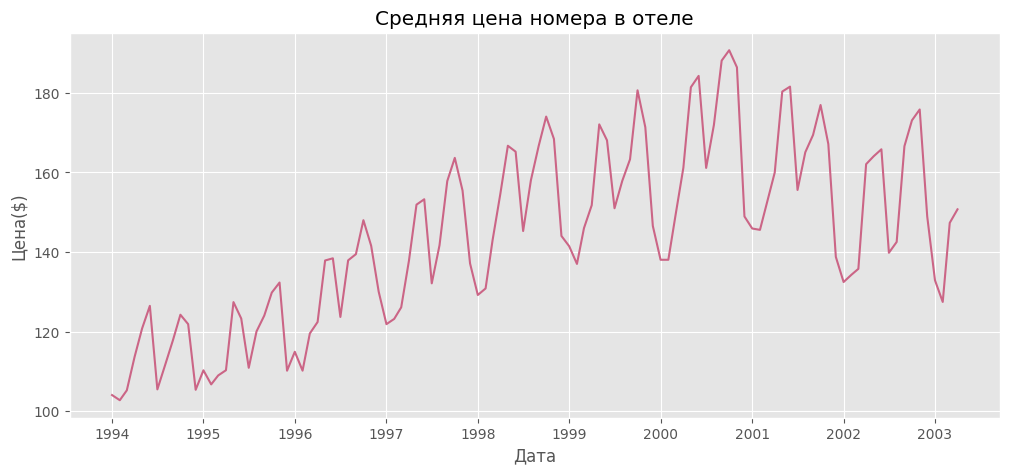

In [ ]:
# Построим график временного ряда
y = data['x2']

plt.figure(figsize=(12,5))
plt.plot(y, color = '#CB6586')
plt.title('Средняя цена номера в отеле')
plt.xlabel('Дата')
plt.ylabel('Цена($)')
plt.show()

По графику временного ряда наблюдается линейный тренд и годовая сезонность. Амплитуда сезонных колебаний увеличивается со временем, что указывает на мультипликативный характер сезонности.

In [ ]:
# Добавим номер месяца
data['month'] = data.index.month

# Общее среднее значение ряда
overall_mean = data['x2'].mean()

# Расчёт сезонных индексов
seasonal_index = (data.groupby('month')['x2'].mean() / overall_mean)

# Выведем индексы
print(seasonal_index)

month
1     0.883636
2     0.873173
3     0.927179
4     0.990348
5     1.083384
6     1.086335
7     0.946222
8     1.009357
9     1.076146
10    1.128636
11    1.097150
12    0.934619
Name: x2, dtype: float64


После получения сезонных индексов следующим шагом будет удаление сезонности из ряда и построение модели авторегрессии для десезонированных данных.

In [ ]:
# Добавим сезонный индекс каждому наблюдению
data['season_index'] = data['month'].map(seasonal_index)

# Выполним десезонирование
data['deseasonalized'] = (data['x2'] / data['season_index'])

data[['x2', 'season_index', 'deseasonalized']].head()

,x2,season_index,deseasonalized
date,,,
1994-01-01,104.04,0.883636,117.740759
1994-02-01,102.74,0.873173,117.662830
1994-03-01,105.23,0.927179,113.494833
1994-04-01,113.63,0.990348,114.737471
1994-05-01,120.77,1.083384,111.474778


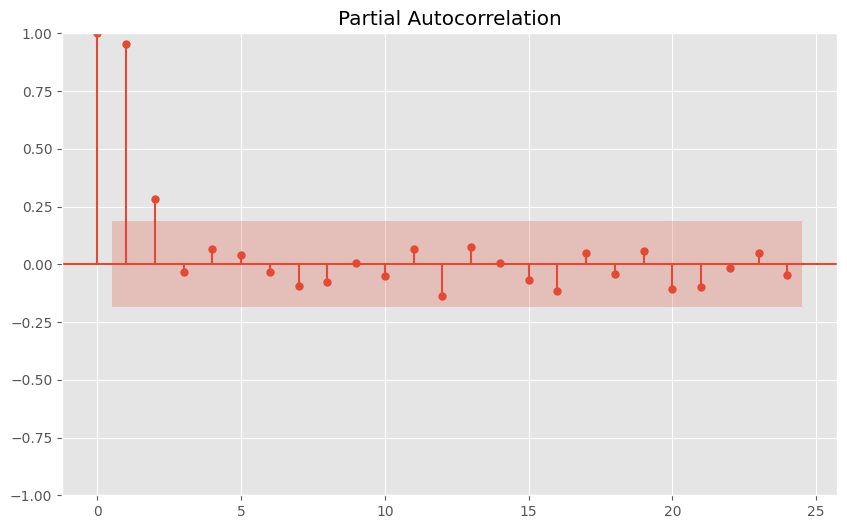

In [ ]:
plt.figure(figsize=(10,6))
plot_pacf(data['deseasonalized'], lags=24, method='ywmle', ax=plt.gca())
plt.show()

По графику PACF видно, что статистически значимые зависимости наблюдаются на лагах 1 и 2.
Следовательно, для описания десезонированного ряда выбрана модель авторегрессии второго порядка AR(2).

In [ ]:
model = AutoReg(data['deseasonalized'], lags=2, old_names=False).fit()

print(model.summary())

                            AutoReg Model Results                             
Dep. Variable:         deseasonalized   No. Observations:                  112
Model:                     AutoReg(2)   Log Likelihood                -322.313
Method:               Conditional MLE   S.D. of innovations              4.532
Date:                Fri, 29 May 2026   AIC                            652.627
Time:                        09:49:17   BIC                            663.428
Sample:                    03-01-1994   HQIC                           657.008
                         - 04-01-2003                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 5.3284      3.440      1.549      0.121      -1.413      12.070
deseasonalized.L1     0.5663      0.088      6.432      0.000       0.394       0.739
deseasonalized.L2     0.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [ ]:
forecast = model.predict(start=len(data), end=len(data) + 7)

In [ ]:
future_months = [(data.index[-1].month + i - 1) % 12 + 1 for i in range(1, 9)]

forecast_final = forecast.copy()

for i in range(8):
    forecast_final.iloc[i] *= seasonal_index[future_months[i]]
forecast_final

,0
2003-05-01,167.985191
2003-06-01,167.294741
2003-07-01,146.236207
2003-08-01,155.880317
2003-09-01,166.362460
2003-10-01,174.525857
2003-11-01,169.752221
2003-12-01,144.667471


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will conta

MAPE: 6.44%


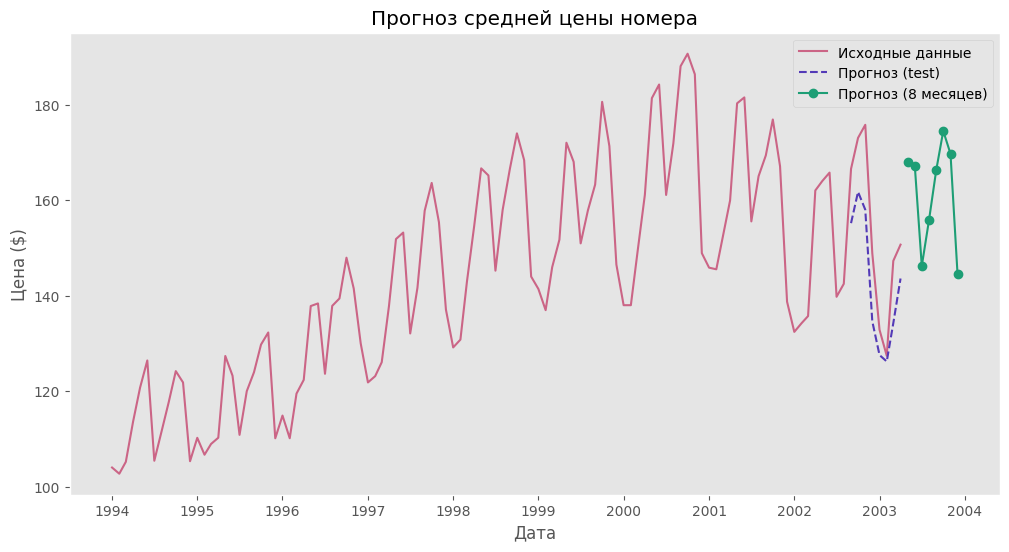

In [ ]:
# Разбивка train/test
train = data.iloc[:-8]
test = data.iloc[-8:]

# Обучение модели на train
model_train = AutoReg(
    train['deseasonalized'],
    lags=2,
    old_names=False).fit()

# Прогноз для test
pred_test = model_train.predict(
    start=len(train),
    end=len(train) + len(test) - 1)

pred_test.index = test.index

# Возвращаем сезонность
test_pred_real = pred_test.copy()
test_pred_real *= data.loc[test.index, 'season_index'].values

# Оценка качества прогноза
mape = mean_absolute_percentage_error(test['x2'], test_pred_real)
print(f"MAPE: {mape:.2%}")

# Финальная модель на всех данных
final_model = AutoReg(
    data['deseasonalized'],
    lags=2,
    old_names=False).fit()

# Прогноз на 8 месяцев
forecast_8 = final_model.predict(
    start=len(data),
    end=len(data) + 7)

# Номера будущих месяцев
future_months = [(data.index[-1].month + i - 1) % 12 + 1 for i in range(1, 9)]

# Возвращаем сезонность
forecast_final = forecast_8.copy()

for i in range(8):
    forecast_final.iloc[i] *= seasonal_index[future_months[i]]

# Индекс будущих дат
future_index = pd.date_range(
    start=data.index[-1] + pd.DateOffset(months=1),
    periods=8,
    freq='MS')

# График
plt.figure(figsize=(12,6))

# Исходные данные
plt.plot(
    data.index,
    data['x2'],
    color='#CB6586',
    label='Исходные данные')

# Прогноз на test
plt.plot(
    test.index,
    test_pred_real,
    '--',
    color='#533AB7',
    label='Прогноз (test)')

# Прогноз на 8 месяцев
plt.plot(
    future_index,
    forecast_final,
    'o-',
    color='#1D9E75',
    label='Прогноз (8 месяцев)')

plt.title('Прогноз средней цены номера')
plt.xlabel('Дата')
plt.ylabel('Цена ($)')
plt.grid()
plt.legend()

plt.show()

**Вывод:** По результатам прогнозирования средней цены номера в отеле методом сезонной декомпозиции полученные значения находятся в диапазоне $136–168, что согласуется с наблюдаемой тенденцией.

Значение MAPE = 6.44% — свидетельствуют о высокой точности модели: средняя ошибка не превышает 6.44% от фактических значений.

Если сравнивать оценку MAPE с моделью SARIMA: значение MAPE составило 6.44% против 10.49%. Это можно объяснить тем, что сезонность во временном ряде имеет устойчивый и ярко выраженный характер, поэтому её предварительное выделение методом сезонных индексов позволило авторегрессионной модели точнее описать оставшуюся динамику ряда.